# Benchmark Statistics
Two sections:
1. **LastFM 1K dataset** — session-level interaction stats
2. **Top-50k songs** — song-level catalog stats, genre enrichment, language inference

In [15]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

LASTFM_PATH = "/project/pi_dagarwal_umass_edu/project_7/hmagapu/user_sessions_lastfm1k_minuser1000_minitem7_sessgap1200_minsesslen10_minhist50.csv"
TOP50K_PATH = "/project/pi_dagarwal_umass_edu/project_7/hmagapu/top_50k_full_augmented_v2.csv"

---
## Section 1: LastFM 1K Dataset

In [16]:
lastfm = pd.read_csv(
    LASTFM_PATH,
    header=None,
    names=["user_id", "timestamp", "artist_mbid", "artist_name", "track_mbid", "track_name", "session_id"]
)
print(f"Loaded {len(lastfm):,} rows")
lastfm.head(3)

Loaded 4,213,960 rows


,user_id,timestamp,artist_mbid,artist_name,track_mbid,track_name,session_id
0,user_000001,2006-08-13T14:55:14.000000,27613b78-1b9d-4ec3-9db5-fa0743465fdd,Herbie Hancock,8e81302a-6cde-4818-8703-43b5356ce0a0,The Essence,2
1,user_000001,2006-08-13T14:59:59.000000,a74b1b7f-71a5-4011-9441-d0b5e4122711,Radiohead,1c0377bb-c00b-4bbe-b4b2-615f13324adc,Idioteque,2
2,user_000001,2006-08-13T15:05:20.000000,477d1c52-3100-4493-a049-473d8f183e23,高木正勝,8f916d23-0510-4ad5-9a7f-8a076c3f14ca,Change Of Seasons,2


In [17]:
timestamps = pd.to_datetime(lastfm["timestamp"], errors="coerce")

n_users        = lastfm["user_id"].nunique()
total_scrobbles= len(lastfm)
unique_tracks  = lastfm["track_name"].str.lower().str.strip().nunique()
unique_artists = lastfm["artist_name"].str.lower().str.strip().nunique()
n_sessions     = lastfm["session_id"].nunique()

session_lengths      = lastfm.groupby("session_id").size()
mean_sess_len        = session_lengths.mean()
median_sess_len      = session_lengths.median()

sparsity = total_scrobbles / (n_users * unique_tracks)

date_range = f"{timestamps.min().date()} to {timestamps.max().date()}"

stats = pd.DataFrame({
    "Metric": [
        "Number of users",
        "Total scrobbles (rows)",
        "Unique tracks",
        "Unique artists",
        "Number of sessions",
        "Mean session length",
        "Median session length",
        "Sparsity (interactions / users x items)",
        "Date range",
    ],
    "Value": [
        f"{n_users:,}",
        f"{total_scrobbles:,}",
        f"{unique_tracks:,}",
        f"{unique_artists:,}",
        f"{n_sessions:,}",
        f"{mean_sess_len:.2f}",
        f"{median_sess_len:.1f}",
        f"{sparsity:.6f}",
        date_range,
    ]
})
stats

,Metric,Value
0,Number of users,814
1,Total scrobbles (rows),"4,213,960"
2,Unique tracks,"295,957"
3,Unique artists,"43,406"
4,Number of sessions,"7,073"
5,Mean session length,595.78
6,Median session length,130.0
7,Sparsity (interactions / users x items),0.017492
8,Date range,2005-02-14 to 2009-06-19


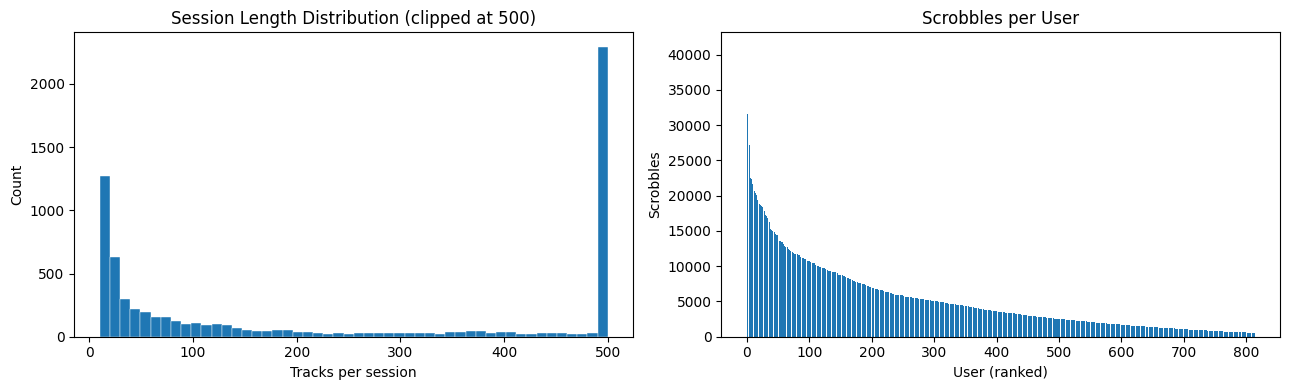

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Session length distribution (clipped for readability)
clip = session_lengths.clip(upper=500)
axes[0].hist(clip, bins=50, edgecolor="white", linewidth=0.3)
axes[0].set_title("Session Length Distribution (clipped at 500)")
axes[0].set_xlabel("Tracks per session")
axes[0].set_ylabel("Count")

# Scrobbles per user
user_counts = lastfm.groupby("user_id").size().sort_values(ascending=False)
axes[1].bar(range(len(user_counts)), user_counts.values)
axes[1].set_title("Scrobbles per User")
axes[1].set_xlabel("User (ranked)")
axes[1].set_ylabel("Scrobbles")

plt.tight_layout()
plt.show()

---
## Section 2: Top-50k Song Catalog

In [18]:
df = pd.read_csv(TOP50K_PATH)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head(3)

Loaded 50,029 rows, 24 columns


,track_index,artist_name,track_name,play_count,track_id,spotify_preview_url,spotify_id,tags,genre,year,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,language
0,0,The Postal Service,Such Great Heights,1016,TRCRCBT128F4260DD1,https://p.scdn.co/mp3-preview/0185e782194fa2fe...,0cs7BfenkAuxTVJv96KMme,"rock, electronic, alternative, indie, pop, ind...",NaN,2003.0,...,-8.447,1.0,0.0469,0.00918,0.23,0.0672,0.199,174.979,4.0,en
1,1,Boy Division,Love Will Tear Us Apart,896,NaN,NaN,NaN,NaN,post-punk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en
2,2,Death Cab For Cutie,Soul Meets Body,884,NaN,NaN,5yc59J3MR3tVDPTOgwgRI5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en


### 2a — Basic Catalog Stats

In [19]:
# Null coverage per column
null_counts = df.isna().sum()
coverage_df = pd.DataFrame({
    "Column": null_counts.index,
    "Empty": null_counts.values,
    "% Empty": (null_counts.values / len(df) * 100).round(1),
    "% Filled": (100 - null_counts.values / len(df) * 100).round(1),
})
coverage_df

,Column,Empty,% Empty,% Filled
0,track_index,0,0.0,100.0
1,artist_name,0,0.0,100.0
2,track_name,0,0.0,100.0
3,play_count,0,0.0,100.0
4,track_id,32076,64.1,35.9
5,spotify_preview_url,17887,35.8,64.2
6,spotify_id,2757,5.5,94.5
7,tags,32139,64.2,35.8
8,genre,21924,43.8,56.2
9,year,17114,34.2,65.8


In [7]:
matched = df["danceability"].notna().sum()
df["duration_min"] = df["duration_ms"] / 60000

catalog_stats = pd.DataFrame({
    "Metric": [
        "Total songs",
        "Unique artists",
        "Unique track names",
        "Songs with audio features",
        "Audio feature coverage %",
        "Songs with spotify_id",
        "Songs with preview URL",
        "Songs with genre tag",
        "Songs with any tags",
        "Avg play count",
        "Median play count",
        "Avg duration (min)",
        "Release year range",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['artist_name'].nunique():,}",
        f"{df['track_name'].nunique():,}",
        f"{matched:,}",
        f"{matched / len(df) * 100:.1f}%",
        f"{df['spotify_id'].notna().sum():,}",
        f"{df['spotify_preview_url'].notna().sum():,}",
        f"{df['genre'].notna().sum():,}",
        f"{df['tags'].notna().sum():,}",
        f"{df['play_count'].mean():.1f}",
        f"{df['play_count'].median():.1f}",
        f"{df['duration_min'].mean():.2f}",
        f"{int(df['year'].dropna().min())} – {int(df['year'].dropna().max())}",
    ]
})
catalog_stats

,Metric,Value
0,Total songs,"50,029"
1,Unique artists,"5,751"
2,Unique track names,"43,503"
3,Songs with audio features,"47,113"
4,Audio feature coverage %,94.2%
5,Songs with spotify_id,"47,272"
6,Songs with preview URL,"32,142"
7,Songs with genre tag,"28,105"
8,Songs with any tags,"17,890"
9,Avg play count,49.7


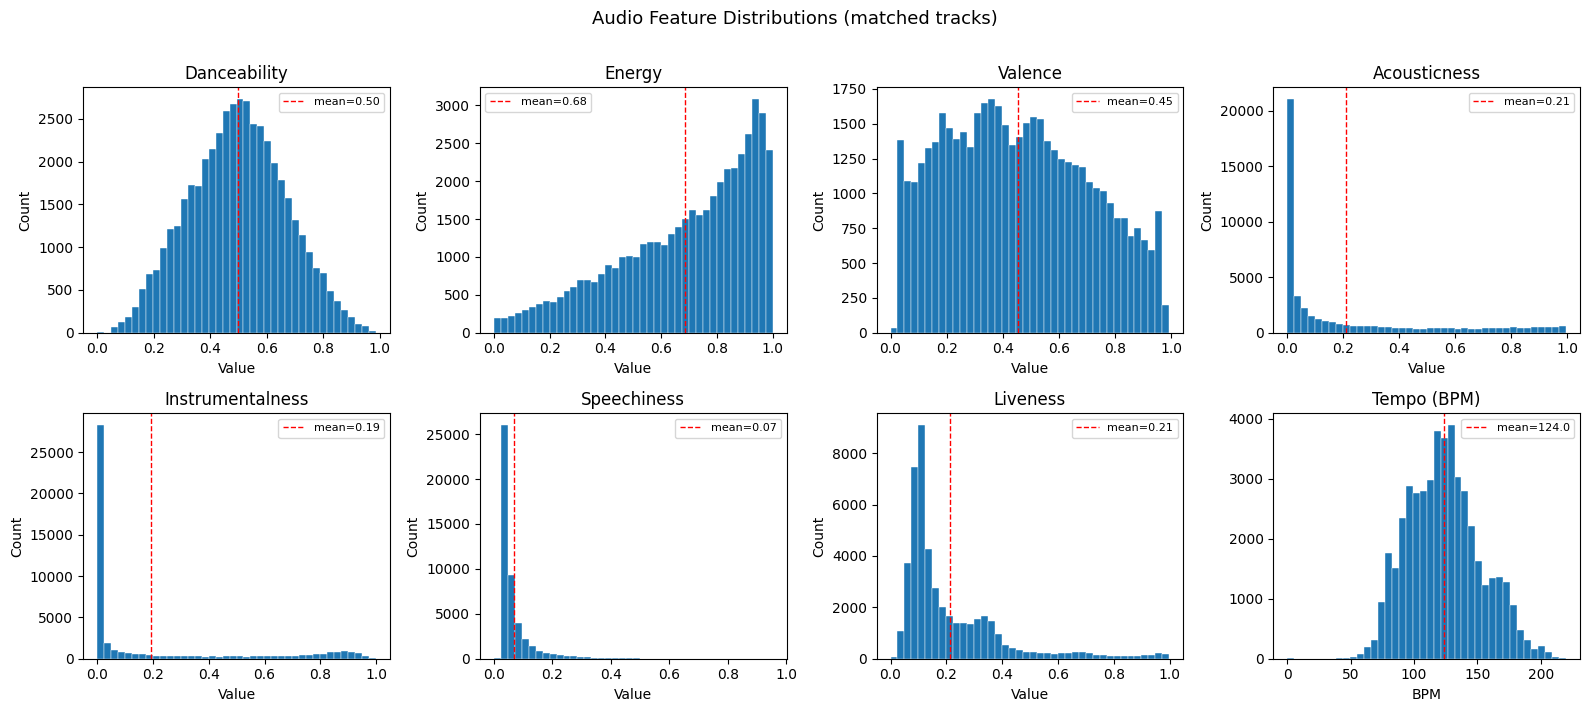

In [8]:
audio_cols = ["danceability", "energy", "valence", "acousticness",
              "instrumentalness", "speechiness", "liveness"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(audio_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, edgecolor="white", linewidth=0.3)
    axes[i].set_title(col.capitalize())
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].axvline(data.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={data.mean():.2f}")
    axes[i].legend(fontsize=8)

# Tempo in the last slot
tempo_data = df["tempo"].dropna()
axes[7].hist(tempo_data, bins=40, edgecolor="white", linewidth=0.3)
axes[7].set_title("Tempo (BPM)")
axes[7].set_xlabel("BPM")
axes[7].axvline(tempo_data.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={tempo_data.mean():.1f}")
axes[7].legend(fontsize=8)

plt.suptitle("Audio Feature Distributions (matched tracks)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

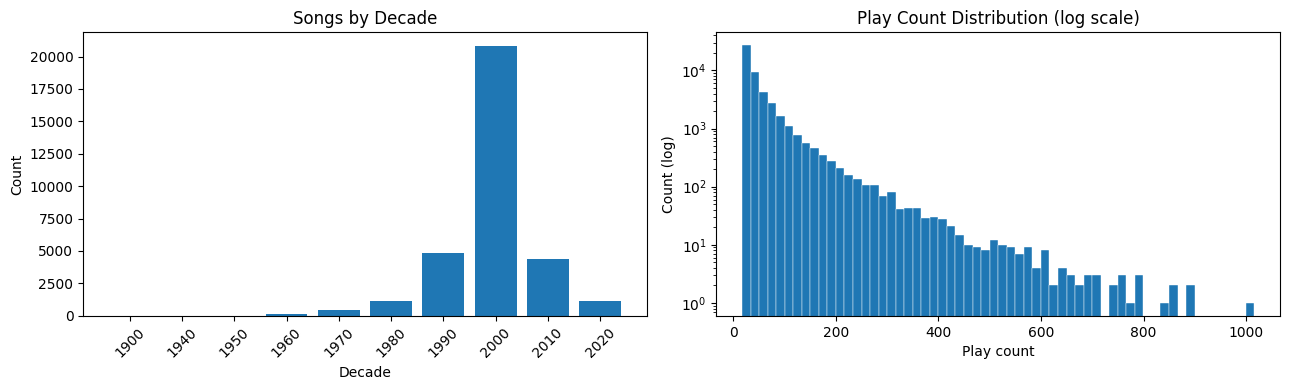

In [9]:
year_counts = df["year"].dropna().astype(int)
decade_counts = (year_counts // 10 * 10).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(decade_counts.index.astype(str), decade_counts.values)
axes[0].set_title("Songs by Decade")
axes[0].set_xlabel("Decade")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(df["play_count"], bins=60, log=True, edgecolor="white", linewidth=0.3)
axes[1].set_title("Play Count Distribution (log scale)")
axes[1].set_xlabel("Play count")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

### 2b — Genre Stats

Genre data sourced from Music Info + MusicBrainz enrichment (run offline via `fetch_musicbrainz.py` and merged into `top_50k_full_augmented_v2.csv`).

Total songs with genre: 28,105 / 50,029 (56.2%)
Unique genres (case-normalized): 81


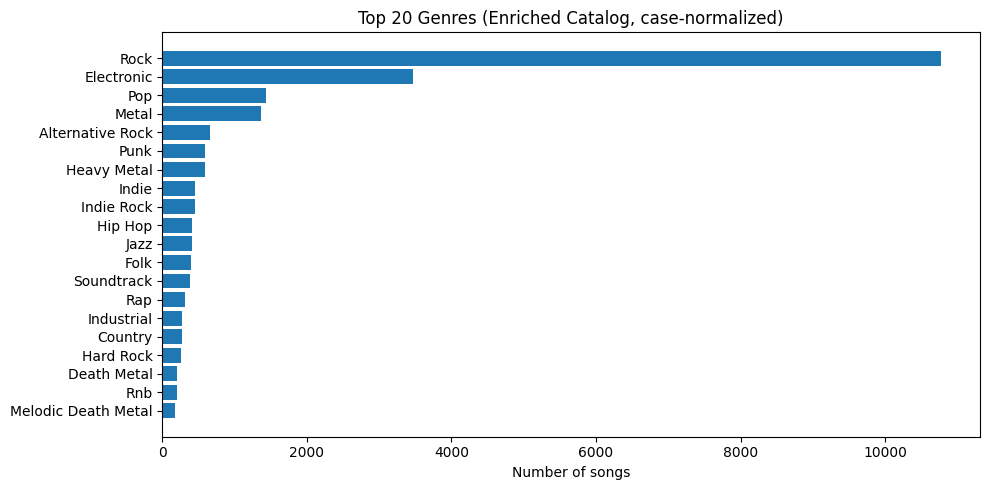

genre
Rock                   10774
Electronic              3463
Pop                     1441
Metal                   1368
Alternative Rock         657
Punk                     595
Heavy Metal              585
Indie                    455
Indie Rock               451
Hip Hop                  417
Jazz                     415
Folk                     401
Soundtrack               384
Rap                      309
Industrial               266
Country                  265
Hard Rock                252
Death Metal              197
Rnb                      196
Melodic Death Metal      174
Name: count, dtype: int64

In [20]:
# Normalize case before counting so 'rock' and 'Rock' merge
genre_normalized = df["genre"].str.strip().str.title()

genre_counts = genre_normalized.value_counts(dropna=True)

print(f"Total songs with genre: {genre_normalized.notna().sum():,} / {len(df):,} ({genre_normalized.notna().mean()*100:.1f}%)")
print(f"Unique genres (case-normalized): {genre_counts.nunique()}")

top20 = genre_counts.head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top20.index[::-1], top20.values[::-1])
ax.set_title("Top 20 Genres (Enriched Catalog, case-normalized)")
ax.set_xlabel("Number of songs")
plt.tight_layout()
plt.show()

top20

### 2c — Language Stats

Language data sourced from MusicBrainz enrichment (run offline and merged into `top_50k_full_augmented_v2.csv`).

Total songs with language: 49,909 / 50,029 (99.8%)
Unique language codes: 42


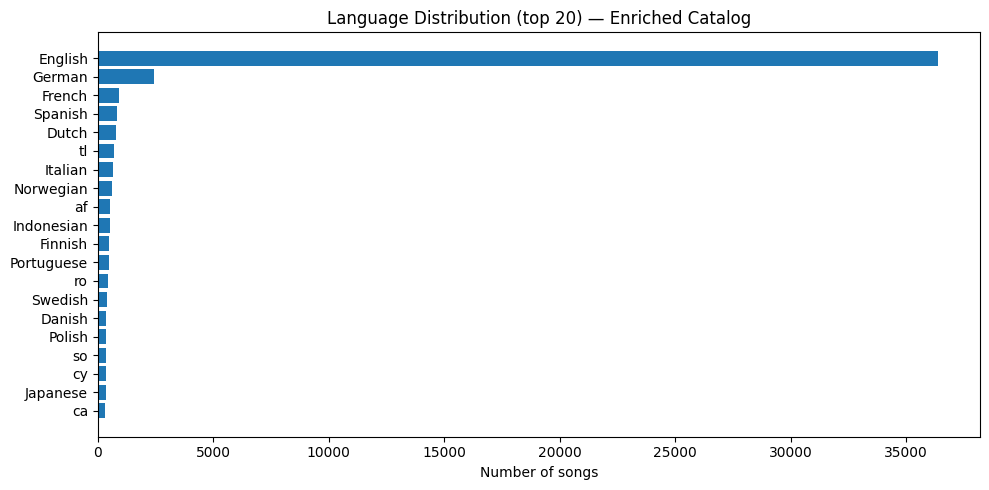

language
English       36373
German         2424
French          921
Spanish         850
Dutch           787
tl              700
Italian         664
Norwegian       600
af              539
Indonesian      537
Finnish         504
Portuguese      503
ro              425
Swedish         394
Danish          371
Polish          370
so              340
cy              336
Japanese        336
ca              325
Name: count, dtype: int64

In [21]:
lang_counts = df["language"].value_counts(dropna=True)

print(f"Total songs with language: {df['language'].notna().sum():,} / {len(df):,} ({df['language'].notna().mean()*100:.1f}%)")
print(f"Unique language codes: {lang_counts.nunique()}")

LANG_NAMES = {
    "en": "English", "fr": "French", "de": "German", "es": "Spanish",
    "pt": "Portuguese", "it": "Italian", "ja": "Japanese", "ko": "Korean",
    "zh": "Chinese", "ru": "Russian", "tr": "Turkish", "ar": "Arabic",
    "hi": "Hindi", "sv": "Swedish", "no": "Norwegian", "da": "Danish",
    "fi": "Finnish", "pl": "Polish", "nl": "Dutch", "el": "Greek",
    "he": "Hebrew", "th": "Thai", "id": "Indonesian", "vi": "Vietnamese",
}

top20_lang = lang_counts.head(20).copy()
top20_lang.index = top20_lang.index.map(lambda c: LANG_NAMES.get(c, c))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top20_lang.index[::-1], top20_lang.values[::-1])
ax.set_title("Language Distribution (top 20) — Enriched Catalog")
ax.set_xlabel("Number of songs")
plt.tight_layout()
plt.show()

top20_lang

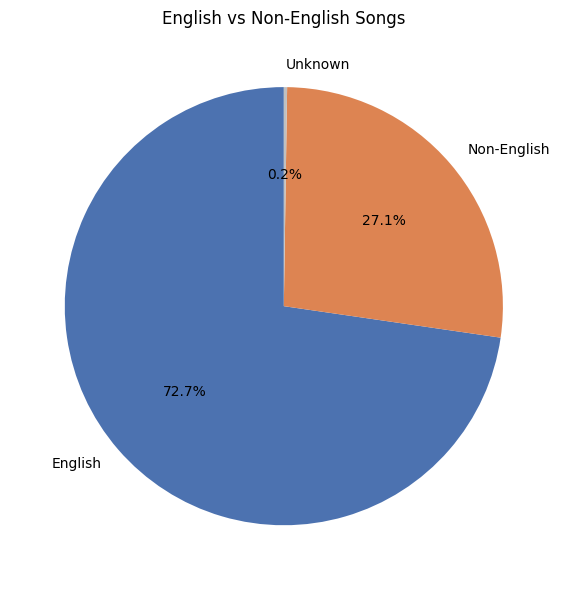

English:     36,373  (72.7%)
Non-English: 13,536  (27.1%)
Unknown:     120  (0.2%)


In [22]:
# English vs non-English breakdown
en_count      = (df["language"] == "en").sum()
non_en_count  = (df["language"].notna() & (df["language"] != "en")).sum()
unknown_count = df["language"].isna().sum()

labels = ["English", "Non-English", "Unknown"]
sizes  = [en_count, non_en_count, unknown_count]
colors = ["#4c72b0", "#dd8452", "#c0c0c0"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
ax.set_title("English vs Non-English Songs")
plt.tight_layout()
plt.show()

print(f"English:     {en_count:,}  ({en_count/len(df)*100:.1f}%)")
print(f"Non-English: {non_en_count:,}  ({non_en_count/len(df)*100:.1f}%)")
print(f"Unknown:     {unknown_count:,}  ({unknown_count/len(df)*100:.1f}%)")